In [20]:
# ============================================================================
# PHASE 9: LEAD SCORING & PRODUCT ADOPTION
# Jupyter Notebook - Data Prep + Model Training
# ============================================================================

# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)
import lightgbm as lgb
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful")


✅ All imports successful


In [21]:
import sys
import os
from pathlib import Path
from dotenv import load_dotenv

# 1. Resolve paths relative to notebooks/
notebook_dir = Path.cwd()
backend_dir = (notebook_dir / ".." / "backend").resolve()

# 2. Add backend/ to sys.path so 'import app' works
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))

# 3. Load backend/.env (or change path to root .env if stored there)
env_file = backend_dir / ".env"
load_dotenv(dotenv_path=env_file)

# 4. Re-import Settings and MongoDBManager AFTER loading environment variables
from app.config import settings
from app.database import MongoDBManager

# Verify the URL is correctly loaded
print("MongoDB URL loaded:", settings.mongodb_url[:20] + "...")

MongoDB URL loaded: mongodb+srv://MSRobo...


In [22]:
import pandas as pd
from app.database import MongoDBManager

# 1. Connect to MongoDB
await MongoDBManager.connect_db()

# 2. Retrieve documents from the collection
# Limit set to 100 records for quick display; set to None or a higher number if needed
raw_docs = await MongoDBManager.collection.find().to_list(length=100)

# 3. Convert to Pandas DataFrame
df = pd.DataFrame(raw_docs)

# 4. Clean up ObjectId display (_id column)
if "_id" in df.columns:
    df["_id"] = df["_id"].astype(str)

# 5. Display table summary and head
print(f"Total retrieved rows: {len(df)}")
df.head()

Total retrieved rows: 34


,_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,member_id,member_name,prediction,churn_probability,risk_bucket,days_to_churn,created_at,top_risk_factors
0,6a7e78c66fb2299965925a4f,452,France,M,24,9,0.00,3,0,0,99495.35,MEM_00000,Member MEM_00000,1,0.668468,Medium Risk,45.0,2026-08-14 02:09:10.982,NaN
1,6a7e78c66fb2299965925a50,785,Spain,M,61,3,125417.12,2,1,0,52371.80,MEM_00001,Member MEM_00001,1,0.865653,High Risk,14.0,2026-08-14 02:09:10.999,NaN
2,6a7e78c76fb2299965925a51,698,Spain,M,25,7,161064.42,2,1,1,121453.51,MEM_00002,Member MEM_00002,0,0.252482,Safe,NaN,2026-08-14 02:09:11.014,NaN
3,6a7e78c76fb2299965925a52,620,France,M,64,6,113945.25,2,1,0,43770.46,MEM_00003,Member MEM_00003,1,0.875636,High Risk,14.0,2026-08-14 02:09:11.027,NaN
4,6a7e78c76fb2299965925a53,456,France,M,52,8,118864.58,2,1,1,129004.73,MEM_00004,Member MEM_00004,1,0.530450,Medium Risk,45.0,2026-08-14 02:09:11.039,NaN


In [23]:

# ============================================================================
# STEP 1: LOAD EXISTING MEMBER DATA
# ============================================================================
# Cell 2: Load 10K members from Phase 1

# Assuming you saved processed data from Phase 1
# If not using saved file, load from MongoDB

members_df = pd.read_csv("../data/raw/bank_churn.csv")

print(f"✅ Loaded {len(members_df)} members from CSV")
print(f"\nColumns: {members_df.columns.tolist()}")
print(f"\nShape: {members_df.shape}")
print(f"\nFirst row:\n{members_df.iloc[0]}")


✅ Loaded 10000 members from CSV

Columns: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Shape: (10000, 12)

First row:
customer_id          15634602
credit_score              619
country                France
gender                 Female
age                        42
tenure                      2
balance                   0.0
products_number             1
credit_card                 1
active_member               1
estimated_salary    101348.88
churn                       1
Name: 0, dtype: object


In [24]:
np.random.seed(42)

products_df = pd.DataFrame()

# ---- PRODUCT 1: CREDIT CARD ----
products_df['credit_card'] = members_df['credit_card'].astype(int)
print(f"Credit Card Adoption Rate: {products_df['credit_card'].mean():.1%}")

# ---- PRODUCT 2: PERSONAL LOAN ----
loan_prob = (
    0.15 * (members_df['products_number'] / 4) +
    0.10 * (members_df['tenure'] / 10) +
    0.05 * members_df['active_member']
)
loan_prob = np.clip(loan_prob, 0, 1)
products_df['personal_loan'] = (np.random.rand(len(members_df)) < loan_prob).astype(int)
print(f"Personal Loan Adoption Rate: {products_df['personal_loan'].mean():.1%}")

# ---- PRODUCT 3: INVESTMENT ACCOUNT ----
investment_prob = (
    0.20 * (members_df['balance'] / 250000) +
    0.15 * ((members_df['credit_score'] - 350) / 500) +
    0.05 * (members_df['age'] / 96)
)
investment_prob = np.clip(investment_prob, 0, 1)
products_df['investment'] = (np.random.rand(len(members_df)) < investment_prob).astype(int)
print(f"Investment Account Adoption Rate: {products_df['investment'].mean():.1%}")

# ---- PRODUCT 4: MOBILE BANKING ----
mobile_prob = (
    0.20 * (1 - members_df['age'] / 96) +
    0.15 * members_df['active_member'] +
    0.10 * (members_df['products_number'] / 4)
)
mobile_prob = np.clip(mobile_prob, 0, 1)
products_df['mobile_banking'] = (np.random.rand(len(members_df)) < mobile_prob).astype(int)
print(f"Mobile Banking Adoption Rate: {products_df['mobile_banking'].mean():.1%}")

# ---- PRODUCT 5: PREMIUM ACCOUNT ----
premium_prob = (
    0.25 * (members_df['tenure'] / 10) +
    0.20 * (members_df['balance'] / 250000) +
    0.10 * ((members_df['credit_score'] - 350) / 500)
)
premium_prob = np.clip(premium_prob, 0, 1)
products_df['premium_account'] = (np.random.rand(len(members_df)) < premium_prob).astype(int)
print(f"Premium Account Adoption Rate: {products_df['premium_account'].mean():.1%}")

# Add non-duplicate columns to main dataframe
new_cols = [col for col in products_df.columns if col not in members_df.columns]
members_df = pd.concat([members_df, products_df[new_cols]], axis=1)

print("\n✅ Product adoption labels generated")
print(f"\nProduct Adoption Summary:\n{products_df.sum()}")
print(f"\nProduct Adoption Rates:\n{products_df.mean()}")

Credit Card Adoption Rate: 70.5%
Personal Loan Adoption Rate: 13.5%
Investment Account Adoption Rate: 17.2%
Mobile Banking Adoption Rate: 23.0%
Premium Account Adoption Rate: 25.2%

✅ Product adoption labels generated

Product Adoption Summary:
credit_card        7055
personal_loan      1349
investment         1720
mobile_banking     2300
premium_account    2516
dtype: int64

Product Adoption Rates:
credit_card        0.7055
personal_loan      0.1349
investment         0.1720
mobile_banking     0.2300
premium_account    0.2516
dtype: float64


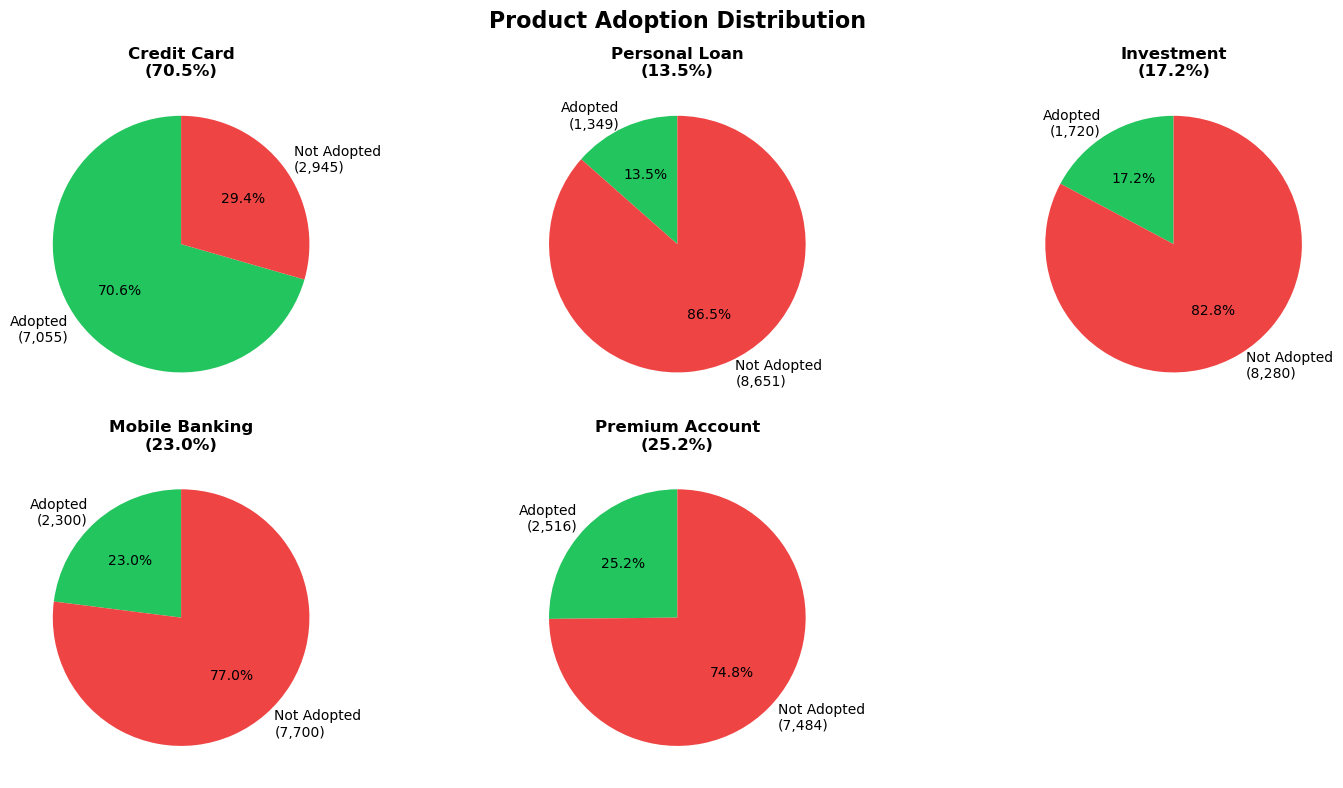

✅ Visualization saved: product_adoption_distribution.png


In [25]:
# Cell 4: Visualize product adoption distribution

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Product Adoption Distribution', fontsize=16, fontweight='bold')

products = ['credit_card', 'personal_loan', 'investment', 'mobile_banking', 'premium_account']

for idx, product in enumerate(products):
    ax = axes[idx // 3, idx % 3]
    adoption_rate = products_df[product].mean()
    
    counts = [members_df[product].sum(), len(members_df) - members_df[product].sum()]
    labels = [f'Adopted\n({counts[0]:,})', f'Not Adopted\n({counts[1]:,})']
    colors = ['#22c55e', '#ef4444']
    
    ax.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{product.replace("_", " ").title()}\n({adoption_rate:.1%})', fontweight='bold')

# Remove extra subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('product_adoption_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: product_adoption_distribution.png")


In [26]:

# ============================================================================
# STEP 3: PREPARE FEATURES FOR MODELING
# ============================================================================
# Cell 5: Select and preprocess features
# Select numerical features AND existing credit_card status
X = members_df[[
    'credit_score', 'age', 'tenure', 'balance', 'products_number',
    'estimated_salary', 'active_member', 'credit_card'
]].copy()

# One-hot encode country
country_dummies = pd.get_dummies(members_df['country'], prefix='country', drop_first=False)
country_dummies = country_dummies.rename(columns={
    'country_France': 'France',
    'country_Germany': 'Germany',
    'country_Spain': 'Spain'
})

# One-hot encode gender
gender_dummies = pd.get_dummies(members_df['gender'], prefix='gender', drop_first=False)
gender_dummies = gender_dummies.rename(columns={
    'gender_F': 'Female',
    'gender_M': 'Male'
})

# Combine all feature dataframes
X = pd.concat([X, country_dummies, gender_dummies], axis=1)

# Rename credit_card column to avoid target variable confusion
X = X.rename(columns={'credit_card': 'credit_card_existing'})

# Normalize numerical features
scaler = StandardScaler()
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(f"Features shape: {X_scaled.shape}") # Will now print: (10000, 13)
print(f"Feature names: {X_scaled.columns.tolist()}")

Features shape: (10000, 13)
Feature names: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'active_member', 'credit_card_existing', 'France', 'Germany', 'Spain', 'gender_Female', 'gender_Male']


In [27]:

# ============================================================================
# STEP 4: TRAIN 5 SEPARATE LIGHTGBM MODELS
# ============================================================================
# Cell 6: Train models for each product

products = {
    'credit_card': 'Credit Card Adoption',
    'personal_loan': 'Personal Loan Adoption',
    'investment': 'Investment Account Adoption',
    'mobile_banking': 'Mobile Banking Adoption',
    'premium_account': 'Premium Account Adoption'
}

trained_models = {}
model_performance = {}

print("=" * 70)
print("TRAINING 5 LIGHTGBM MODELS FOR PRODUCT ADOPTION")
print("=" * 70)

for product_key, product_name in products.items():
    print(f"\n{'=' * 70}")
    print(f"Training: {product_name}")
    print(f"{'=' * 70}")
    
    # Get target
    y = members_df[product_key].astype(int)
    
    print(f"Target distribution:")
    print(f"  Adopted: {y.sum():,} ({y.mean():.1%})")
    print(f"  Not Adopted: {len(y) - y.sum():,} ({1 - y.mean():.1%})")
    
    # Train/test split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # LightGBM model with hyperparameters
    model = lgb.LGBMClassifier(
        n_estimators=150,
        max_depth=7,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        class_weight='balanced'  # Handle any class imbalance
    )
    
    # Train
    print("\nTraining...")
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 5 Feature Importance:")
    for idx, row in feature_importance.head(5).iterrows():
        print(f"  {row['feature']:20s}: {row['importance']:.4f}")
    
    # Store model and results
    trained_models[product_key] = model
    model_performance[product_key] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'feature_importance': feature_importance,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

print("\n✅ All 5 models trained successfully")


TRAINING 5 LIGHTGBM MODELS FOR PRODUCT ADOPTION

Training: Credit Card Adoption
Target distribution:
  Adopted: 7,055 (70.5%)
  Not Adopted: 2,945 (29.4%)

Training...

Test Set Performance:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000

Top 5 Feature Importance:
  estimated_salary    : 997.0000
  credit_score        : 972.0000
  age                 : 787.0000
  balance             : 652.0000
  tenure              : 425.0000

Training: Personal Loan Adoption
Target distribution:
  Adopted: 1,349 (13.5%)
  Not Adopted: 8,651 (86.5%)

Training...

Test Set Performance:
  Accuracy:  0.7160
  Precision: 0.1689
  Recall:    0.2815
  F1-Score:  0.2111
  ROC-AUC:   0.5501

Top 5 Feature Importance:
  estimated_salary    : 1034.0000
  credit_score        : 910.0000
  age                 : 699.0000
  balance             : 671.0000
  tenure              : 345.0000

Training: Investment Account Adoption
Target distribution:
  Adopted: 1,720 (1


MODEL PERFORMANCE SUMMARY


                 Accuracy  Precision  Recall  F1-Score  ROC-AUC
credit_card        1.0000     1.0000  1.0000    1.0000   1.0000
personal_loan      0.7160     0.1689  0.2815    0.2111   0.5501
investment         0.6580     0.2059  0.3459    0.2581   0.5479
mobile_banking     0.6090     0.2788  0.4413    0.3418   0.5819
premium_account    0.6335     0.3425  0.4970    0.4055   0.6206


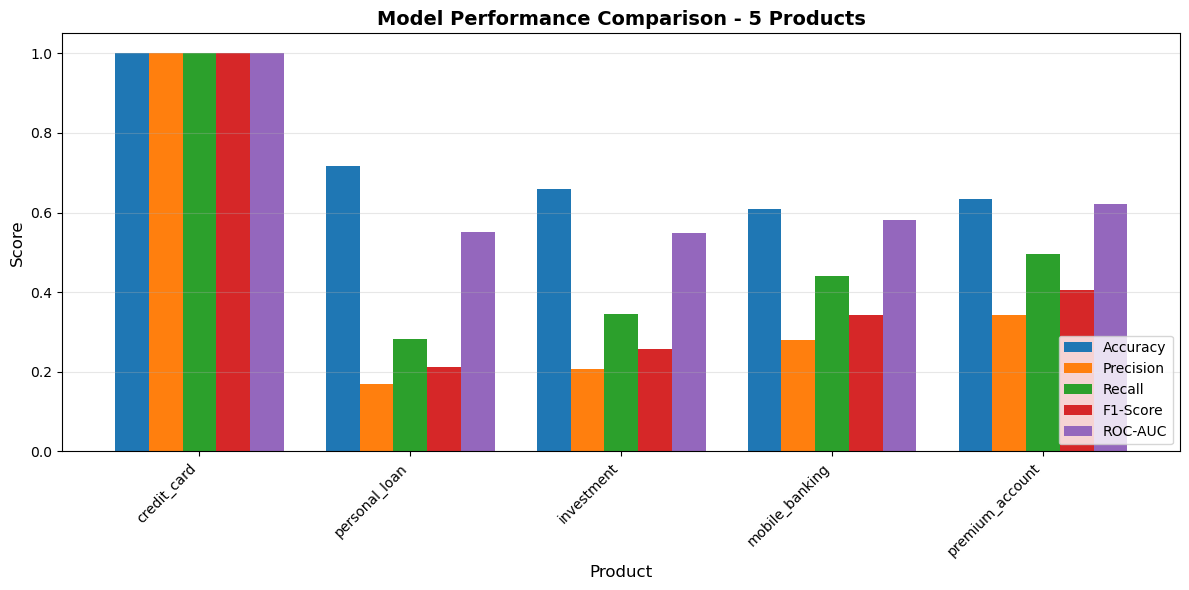

✅ Visualization saved: model_performance_comparison.png


In [28]:

# Cell 7: Performance comparison table

performance_df = pd.DataFrame({
    product: {
        'Accuracy': model_performance[product]['accuracy'],
        'Precision': model_performance[product]['precision'],
        'Recall': model_performance[product]['recall'],
        'F1-Score': model_performance[product]['f1'],
        'ROC-AUC': model_performance[product]['roc_auc']
    }
    for product in products.keys()
}).T

print("\n" + "=" * 70)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(performance_df.round(4))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
performance_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison - 5 Products', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Product', fontsize=12)
ax.legend(loc='lower right')
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: model_performance_comparison.png")


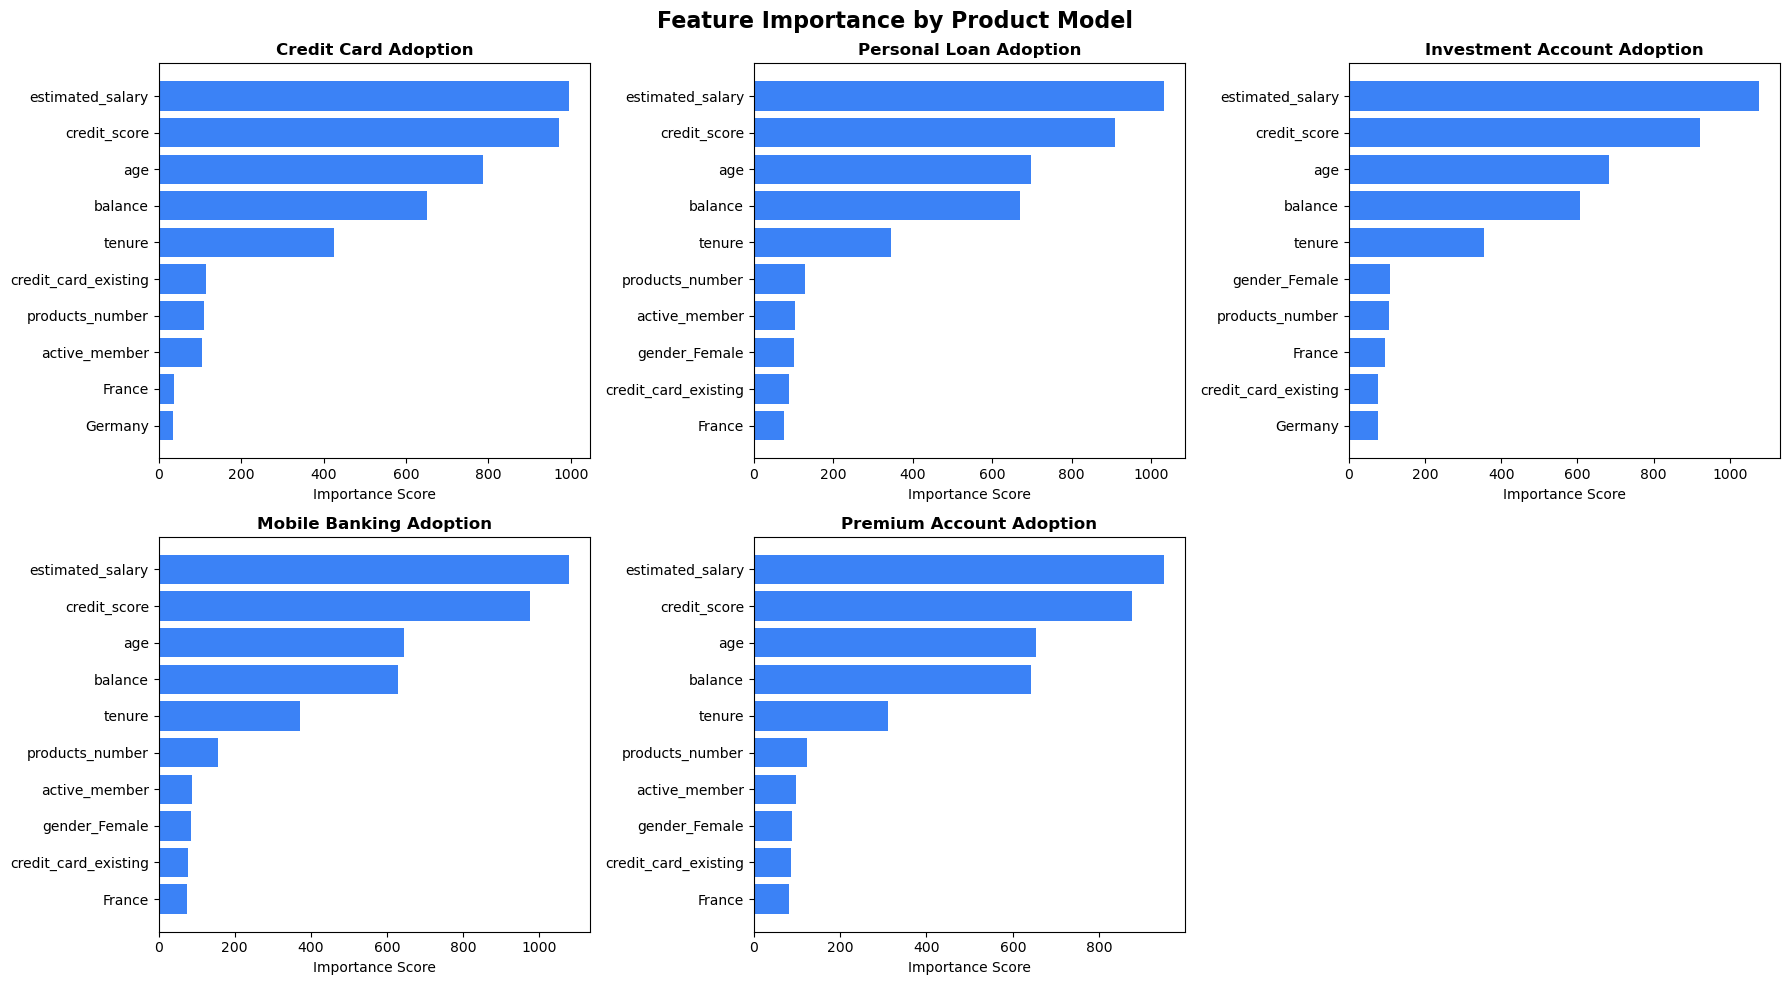

✅ Visualization saved: feature_importance_by_product.png


In [29]:

# ============================================================================
# STEP 5: FEATURE IMPORTANCE ANALYSIS
# ============================================================================
# Cell 8: Visualize feature importance for all models

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Importance by Product Model', fontsize=16, fontweight='bold')

product_list = list(products.keys())

for idx, product in enumerate(product_list):
    ax = axes[idx // 3, idx % 3]
    
    # Get top 10 features
    feature_imp = model_performance[product]['feature_importance'].head(10)
    
    ax.barh(feature_imp['feature'], feature_imp['importance'], color='#3b82f6')
    ax.set_title(products[product], fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()

# Remove extra subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('feature_importance_by_product.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: feature_importance_by_product.png")


In [30]:

# ============================================================================
# STEP 6: SCORE ALL MEMBERS FOR LEAD RANKING
# ============================================================================
# Cell 9: Generate lead scores for all members

# Re-train models on full dataset for production scoring
trained_models_full = {}

print("\n" + "=" * 70)
print("RETRAINING MODELS ON FULL DATASET FOR PRODUCTION")
print("=" * 70)

for product_key, product_name in products.items():
    print(f"\nRetraining: {product_name}...")
    
    y = members_df[product_key].astype(int)
    
    model = lgb.LGBMClassifier(
        n_estimators=150,
        max_depth=7,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        class_weight='balanced'
    )
    
    model.fit(X_scaled, y)
    trained_models_full[product_key] = model

print("✅ All models retrained on full dataset")



RETRAINING MODELS ON FULL DATASET FOR PRODUCTION

Retraining: Credit Card Adoption...

Retraining: Personal Loan Adoption...

Retraining: Investment Account Adoption...

Retraining: Mobile Banking Adoption...

Retraining: Premium Account Adoption...
✅ All models retrained on full dataset


In [31]:

# Cell 10: Score all members for lead ranking

# Get predictions for all members
lead_scores = pd.DataFrame()
lead_scores['member_id'] = members_df.get('member_id', [f'MEM_{i:05d}' for i in range(len(members_df))])

# Add member info
lead_scores['age'] = members_df['age'].values
lead_scores['country'] = members_df['country'].values
lead_scores['balance'] = members_df['balance'].values

# Score each product
for product_key, product_name in products.items():
    model = trained_models_full[product_key]
    probabilities = model.predict_proba(X_scaled)[:, 1]
    lead_scores[f'{product_key}_score'] = probabilities

# Calculate top product recommendation
product_cols = [f'{p}_score' for p in products.keys()]
lead_scores['top_product'] = lead_scores[product_cols].idxmax(axis=1).str.replace('_score', '')
lead_scores['top_score'] = lead_scores[product_cols].max(axis=1)

print(f"✅ Lead scores calculated for {len(lead_scores)} members")
print(f"\nFirst 10 leads:\n{lead_scores.head(10)}")


✅ Lead scores calculated for 10000 members

First 10 leads:
   member_id  age  country    balance  credit_card_score  personal_loan_score  \
0  MEM_00000   42   France       0.00           0.999995             0.459638   
1  MEM_00001   41    Spain   83807.86           0.000005             0.384286   
2  MEM_00002   42   France  159660.80           0.999995             0.262378   
3  MEM_00003   39   France       0.00           0.000006             0.146410   
4  MEM_00004   43    Spain  125510.82           0.999995             0.120116   
5  MEM_00005   44    Spain  113755.78           0.999994             0.412529   
6  MEM_00006   50   France       0.00           0.999994             0.649654   
7  MEM_00007   29  Germany  115046.74           0.999997             0.142999   
8  MEM_00008   44   France  142051.07           0.000005             0.340193   
9  MEM_00009   27   France  134603.88           0.999995             0.172227   

   investment_score  mobile_banking_score  premi

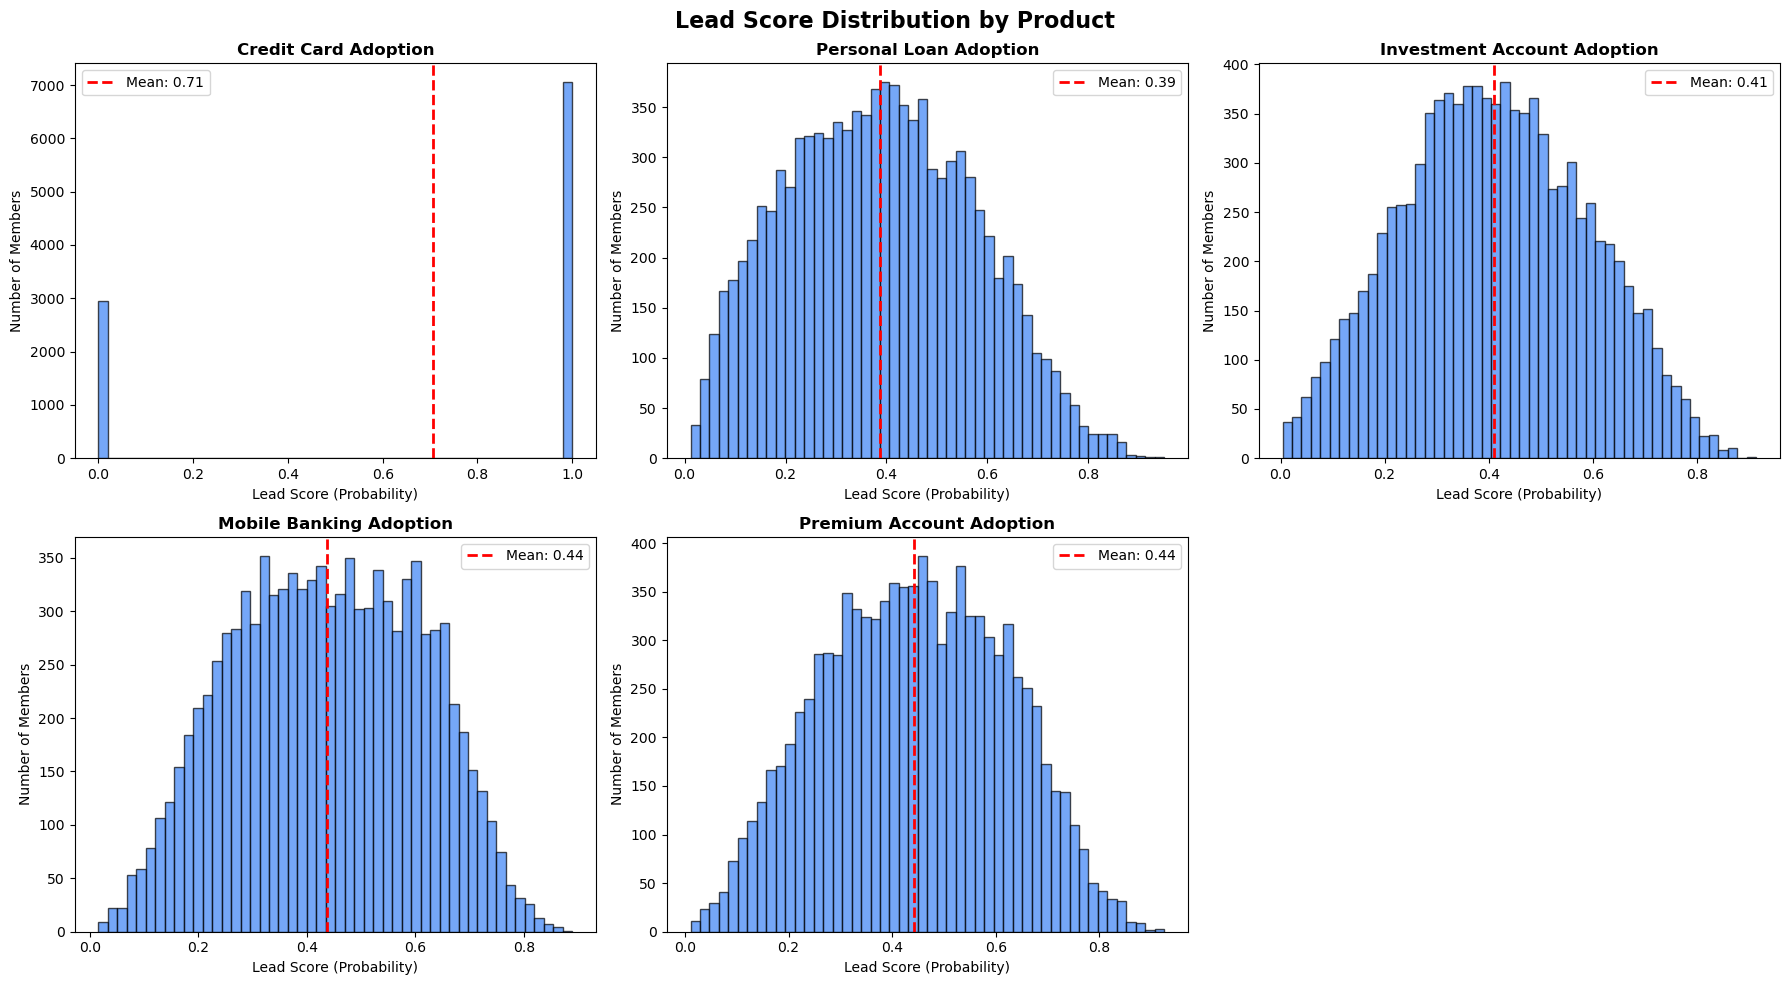

✅ Visualization saved: lead_score_distribution.png


In [32]:

# Cell 11: Visualize lead score distribution

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Lead Score Distribution by Product', fontsize=16, fontweight='bold')

for idx, product in enumerate(product_list):
    ax = axes[idx // 3, idx % 3]
    
    score_col = f'{product}_score'
    data = lead_scores[score_col]
    
    ax.hist(data, bins=50, color='#3b82f6', alpha=0.7, edgecolor='black')
    ax.set_title(products[product], fontweight='bold')
    ax.set_xlabel('Lead Score (Probability)')
    ax.set_ylabel('Number of Members')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
    ax.legend()

# Remove extra subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('lead_score_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: lead_score_distribution.png")


In [33]:

# ============================================================================
# STEP 7: EXPORT RESULTS
# ============================================================================
# Cell 12: Save trained models

models_dir = 'models'
import os
os.makedirs(models_dir, exist_ok=True)

for product_key, model in trained_models_full.items():
    model_path = f'{models_dir}/lead_model_{product_key}.joblib'
    joblib.dump(model, model_path)
    print(f"✅ Saved: {model_path}")

# Save scaler
scaler_path = f'{models_dir}/lead_scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f"✅ Saved: {scaler_path}")

# Save feature names
feature_names_path = f'{models_dir}/lead_feature_names.joblib'
joblib.dump(X.columns.tolist(), feature_names_path)
print(f"✅ Saved: {feature_names_path}")


✅ Saved: models/lead_model_credit_card.joblib
✅ Saved: models/lead_model_personal_loan.joblib
✅ Saved: models/lead_model_investment.joblib
✅ Saved: models/lead_model_mobile_banking.joblib
✅ Saved: models/lead_model_premium_account.joblib
✅ Saved: models/lead_scaler.joblib
✅ Saved: models/lead_feature_names.joblib


In [34]:

# Cell 13: Export lead scores to CSV

lead_scores_csv = 'lead_scores_all_members.csv'
lead_scores.to_csv(lead_scores_csv, index=False)
print(f"✅ Saved: {lead_scores_csv}")

# Export top 100 leads per product
print("\n" + "=" * 70)
print("TOP 100 LEADS BY PRODUCT")
print("=" * 70)

for product_key, product_name in products.items():
    score_col = f'{product_key}_score'
    top_leads = lead_scores.nlargest(100, score_col)[[
        'member_id', 'age', 'country', 'balance', score_col
    ]].copy()
    top_leads = top_leads.rename(columns={score_col: 'lead_score'})
    
    csv_file = f'top_leads_{product_key}.csv'
    top_leads.to_csv(csv_file, index=False)
    print(f"✅ Saved: {csv_file} ({len(top_leads)} members)")
    print(f"   Top score: {top_leads['lead_score'].max():.4f}")
    print(f"   Avg score: {top_leads['lead_score'].mean():.4f}")


✅ Saved: lead_scores_all_members.csv

TOP 100 LEADS BY PRODUCT
✅ Saved: top_leads_credit_card.csv (100 members)
   Top score: 1.0000
   Avg score: 1.0000
✅ Saved: top_leads_personal_loan.csv (100 members)
   Top score: 0.9504
   Avg score: 0.8381
✅ Saved: top_leads_investment.csv (100 members)
   Top score: 0.9142
   Avg score: 0.8216
✅ Saved: top_leads_mobile_banking.csv (100 members)
   Top score: 0.8893
   Avg score: 0.8063
✅ Saved: top_leads_premium_account.csv (100 members)
   Top score: 0.9256
   Avg score: 0.8410


In [35]:

# Cell 14: Summary statistics

print("\n" + "=" * 70)
print("PHASE 9 SUMMARY")
print("=" * 70)

print(f"\n📊 Data:")
print(f"   Members analyzed: {len(members_df):,}")
print(f"   Features per model: {len(X.columns)}")
print(f"   Products: {len(products)}")

print(f"\n🤖 Models:")
print(f"   Algorithm: LightGBM")
print(f"   Models trained: {len(trained_models_full)}")
print(f"   Average ROC-AUC: {performance_df['ROC-AUC'].mean():.4f}")

print(f"\n📁 Outputs:")
print(f"   Models saved: 5 (in models/ directory)")
print(f"   Scaler saved: 1")
print(f"   Feature names saved: 1")
print(f"   Lead scores CSV: 1 (all members)")
print(f"   Top 100 CSVs: 5 (per product)")
print(f"   Visualizations: 3 PNG files")

print(f"\n✅ Phase 9 Notebook Complete!")


PHASE 9 SUMMARY

📊 Data:
   Members analyzed: 10,000
   Features per model: 13
   Products: 5

🤖 Models:
   Algorithm: LightGBM
   Models trained: 5
   Average ROC-AUC: 0.6601

📁 Outputs:
   Models saved: 5 (in models/ directory)
   Scaler saved: 1
   Feature names saved: 1
   Lead scores CSV: 1 (all members)
   Top 100 CSVs: 5 (per product)
   Visualizations: 3 PNG files

✅ Phase 9 Notebook Complete!
